Maria Navarro  
March 24, 2024  
Healthcare Data & Analytics  
Unsupervised Learning for Pattern Recognition   
Comparing Predictive Analytics Models Using ROC curves

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, precision_score, accuracy_score, recall_score, roc_curve, roc_auc_score, precision_recall_curve, confusion_matrix

In [33]:
# Read dataset
df = pd.read_excel('G:/My Drive/Spring 2024/Advanced_Healthcare/Week3/dataR2.xlsx')

In [34]:
df.head()

,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP.1,Classification
0,48,23.500000,70,2.707,0.467409,8.8071,9.702400,7.99585,417.114,1
1,83,20.690495,92,3.115,0.706897,8.8438,5.429285,4.06405,468.786,1
2,82,23.124670,91,4.498,1.009651,17.9393,22.432040,9.27715,554.697,1
3,68,21.367521,77,3.226,0.612725,9.8827,7.169560,12.76600,928.220,1
4,86,21.111111,92,3.549,0.805386,6.6994,4.819240,10.57635,773.920,1


In [35]:
# Replace all occurrences of the value 2 with 0 in Classification column
df['Classification'] = df['Classification'].replace(1, 0)
df['Classification'] = df['Classification'].replace(2, 1)

In [36]:
df.describe()

,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP.1,Classification
count,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000
mean,57.301724,27.582111,97.793103,10.012086,2.694988,26.615080,10.180874,14.725966,534.647000,0.551724
std,16.112766,5.020136,22.525162,10.067768,3.642043,19.183294,6.843341,12.390646,345.912663,0.499475
min,24.000000,18.370000,60.000000,2.432000,0.467409,4.311000,1.656020,3.210000,45.843000,0.000000
25%,45.000000,22.973205,85.750000,4.359250,0.917966,12.313675,5.474283,6.881763,269.978250,0.000000
50%,56.000000,27.662416,92.000000,5.924500,1.380939,20.271000,8.352692,10.827740,471.322500,1.000000
75%,71.000000,31.241442,102.000000,11.189250,2.857787,37.378300,11.815970,17.755207,700.085000,1.000000
max,89.000000,38.578759,201.000000,58.460000,25.050342,90.280000,38.040000,82.100000,1698.440000,1.000000


In [37]:
# No null values
df.isnull().sum()

Age               0
BMI               0
Glucose           0
Insulin           0
HOMA              0
Leptin            0
Adiponectin       0
Resistin          0
MCP.1             0
Classification    0
dtype: int64

In [38]:
# We have a balanced dataset
df['Classification'].value_counts()

Classification
1    64
0    52
Name: count, dtype: int64

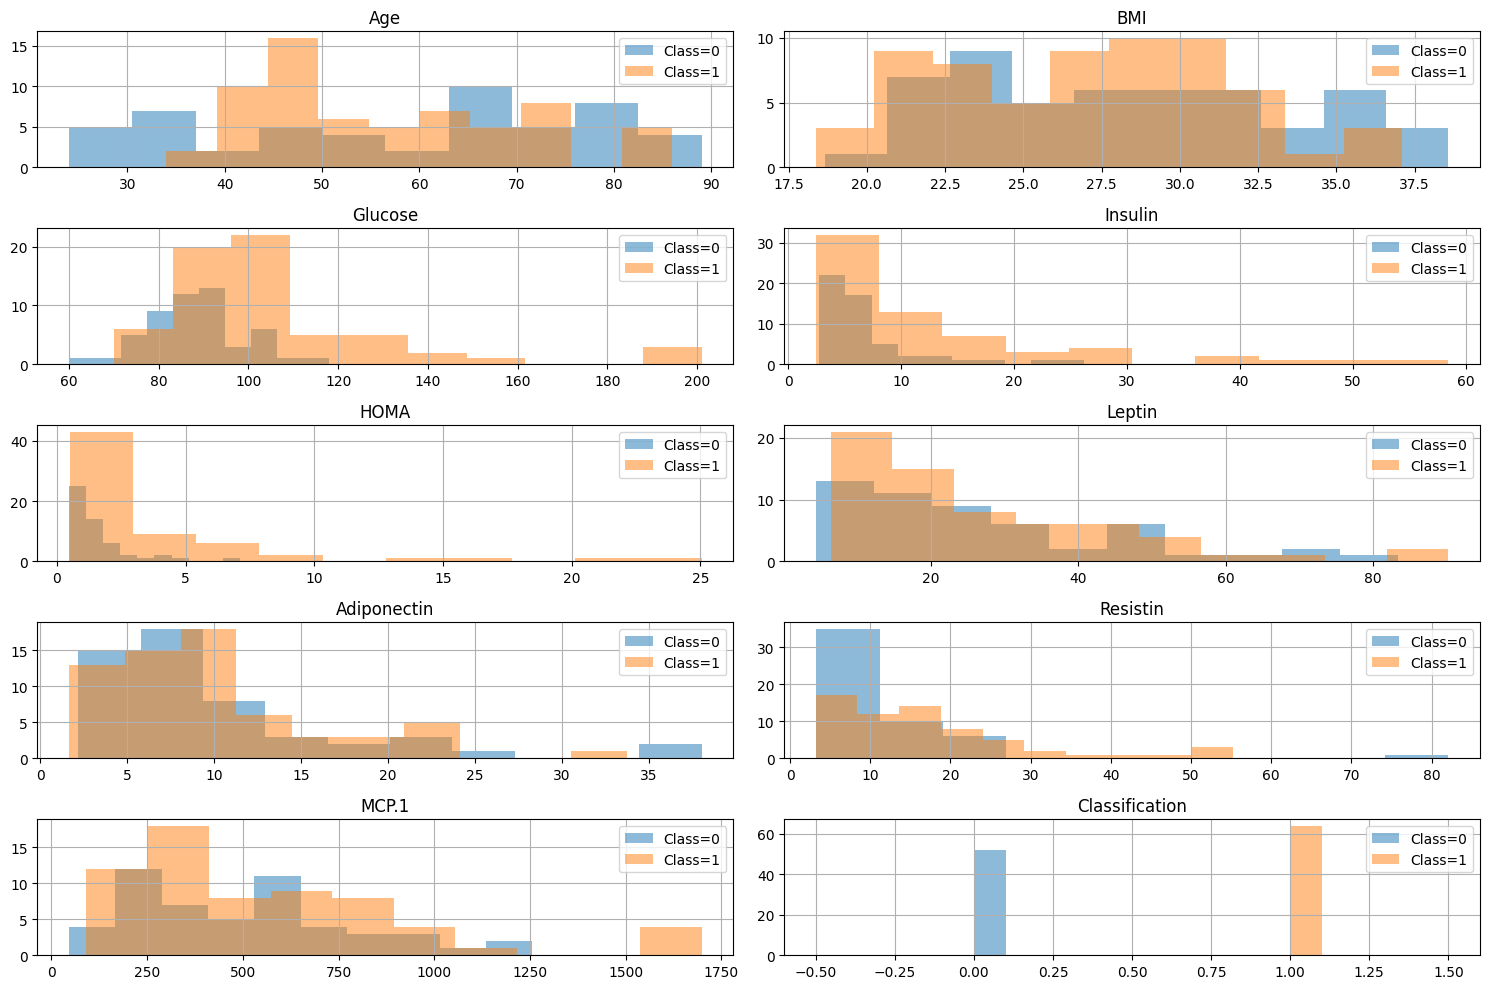

In [39]:
# Define the unique values of the output variable
output_values = df['Classification'].unique()

# Define the number of rows and columns for subplots
num_features = len(df.columns)
num_rows = num_features // 2 + (num_features % 2)
num_cols = 2

# Create a new figure
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 10))

# Flatten the axes array if it's not 2D
if num_features == 1:
    axes = [axes]

# Loop through each feature and plot histograms
for i, feature in enumerate(df.columns):
    row = i // num_cols
    col = i % num_cols
    ax = axes[row][col]
    
    # Plot histograms for each unique value of the output variable
    for val in output_values:
        df[df['Classification'] == val][feature].hist(ax=ax, alpha=0.5, label=f'Class={val}')
    
    ax.set_title(feature)
    ax.legend()
    
# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

In [40]:
# Split data into X and y
X = df.iloc[:, :-1]
y = df.iloc[:, -1:]

In [41]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

In [42]:
# Scale features
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

Model - All Variables

In [43]:
# Train logistic regression model
logreg = LogisticRegression(random_state=21)
logreg.fit(X_train_std, y_train)

# Reshape data into 1D arrays
y_train = np.ravel(y_train)
y_test = np.ravel(y_test)

# Make predictions
y_pred = logreg.predict(X_test_std)

# Measure test accuracy, recall and precision
test_acc = accuracy_score(y_test, y_pred)
print('Logit model accuracy:', test_acc)

test_recall = recall_score(y_test, y_pred)
print('Logit model recall:', test_recall)

test_prec = precision_score(y_test, y_pred)
print('Logit model precision:', test_prec)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)
print('Logit confusion matrix: ')
print(cm)

# Prepare to plot ROC curve
y_scores = logreg.decision_function(X_test_std)
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
auc_score = roc_auc_score(y_test, y_scores)

Logit model accuracy: 0.75
Logit model recall: 0.7692307692307693
Logit model precision: 0.7692307692307693
Logit confusion matrix: 
[[ 8  3]
 [ 3 10]]


C:\Users\mfncn\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1229: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Model 1

In [44]:
# Split data into X and y
X = df[['Age', 'BMI', 'Glucose', 'Resistin']]
y = df['Classification']

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

# Scale features
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

# Train logistic regression model
logreg1 = LogisticRegression(random_state=21)
logreg1.fit(X_train_std, y_train)

# Reshape data into 1D arrays
#y_train = np.ravel(y_train)
#y_test = np.ravel(y_test)

# Make predictions
y_pred1 = logreg1.predict(X_test_std)

# Measure test accuracy, recall and precision
test_acc1 = accuracy_score(y_test, y_pred1)
print('Logit model accuracy:', test_acc1)

test_recall1 = recall_score(y_test, y_pred1)
print('Logit model recall:', test_recall1)

test_prec1 = precision_score(y_test, y_pred1)
print('Logit model precision:', test_prec1)

# Create confustion matrix
cm1 = confusion_matrix(y_test, y_pred1)
print('Logit confusion matrix: ')
print(cm1)

# Prepare to plot ROC curve
y_scores1 = logreg1.decision_function(X_test_std)
fpr1, tpr1, thresholds1 = roc_curve(y_test, y_scores1)
auc_score1 = roc_auc_score(y_test, y_scores1)


Logit model accuracy: 0.7916666666666666
Logit model recall: 0.8461538461538461
Logit model precision: 0.7857142857142857
Logit confusion matrix: 
[[ 8  3]
 [ 2 11]]


In [28]:
logreg1.predict_proba(X_test_std)

array([[9.23314930e-01, 7.66850703e-02],
       [8.58735915e-01, 1.41264085e-01],
       [7.31624846e-03, 9.92683752e-01],
       [1.45216164e-01, 8.54783836e-01],
       [1.65669671e-02, 9.83433033e-01],
       [2.96243440e-01, 7.03756560e-01],
       [7.79139025e-01, 2.20860975e-01],
       [2.07673756e-01, 7.92326244e-01],
       [2.93696094e-01, 7.06303906e-01],
       [1.36615320e-03, 9.98633847e-01],
       [4.34773497e-02, 9.56522650e-01],
       [6.88661143e-01, 3.11338857e-01],
       [2.79651558e-05, 9.99972035e-01],
       [7.93053335e-01, 2.06946665e-01],
       [6.87718079e-01, 3.12281921e-01],
       [4.27694104e-01, 5.72305896e-01],
       [7.34536977e-01, 2.65463023e-01],
       [5.69318394e-01, 4.30681606e-01],
       [2.76687864e-01, 7.23312136e-01],
       [2.17218105e-01, 7.82781895e-01],
       [6.25725803e-01, 3.74274197e-01],
       [5.70493655e-01, 4.29506345e-01],
       [9.45027915e-02, 9.05497209e-01],
       [1.82206874e-01, 8.17793126e-01]])

In [32]:
# Predict probabilities for the test data
y_proba1 = logreg1.predict_proba(X_test_std)
# Initialize variables to store the best F1 score and corresponding threshold
best_f1_score = 0
best_threshold = None

# Calculate F1 score for different thresholds
for threshold in np.linspace(0, 1, 100):
    # Convert probabilities to binary predictions using the current threshold
    y_pred = (y_proba >= threshold).astype(int)
    
    # Calculate F1 score
    current_f1_score = f1_score(y_true, y_pred)
    
    # Update best F1 score and corresponding threshold if current F1 score is higher
    if current_f1_score > best_f1_score:
        best_f1_score = current_f1_score
        best_threshold = threshold

print("Best Threshold based on F1 Score:", best_threshold)
print("Best F1 Score:", best_f1_score)

ValueError: X has 8 features, but LogisticRegression is expecting 4 features as input.

Model 2

In [45]:
# Split data into X and y
X = df[['Age', 'BMI', 'Glucose', 'Resistin', 'HOMA', 'Leptin', 'Adiponectin', 'MCP.1']]
y = df['Classification']

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

# Scale features
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

# Train logistic regression model
logreg2 = LogisticRegression(random_state=21)
logreg2.fit(X_train_std, y_train)

# Reshape data into 1D arrays
#y_train = np.ravel(y_train)
#y_test = np.ravel(y_test)

# Make predictions
y_pred2 = logreg2.predict(X_test_std)

# Measure test accuracy, recall and precision
test_acc2 = accuracy_score(y_test, y_pred2)
print('Logit model accuracy:', test_acc2)

test_recall2 = recall_score(y_test, y_pred2)
print('Logit model recall:', test_recall2)

test_prec2 = precision_score(y_test, y_pred2)
print('Logit model precision:', test_prec2)

# Create confustion matrix
cm2 = confusion_matrix(y_test, y_pred2)
print('Logit confusion matrix: ')
print(cm2)

# Prepare to plot ROC curve
y_scores2 = logreg2.decision_function(X_test_std)
fpr2, tpr2, thresholds2 = roc_curve(y_test, y_scores2)
auc_score2 = roc_auc_score(y_test, y_scores2)

Logit model accuracy: 0.75
Logit model recall: 0.7692307692307693
Logit model precision: 0.7692307692307693
Logit confusion matrix: 
[[ 8  3]
 [ 3 10]]


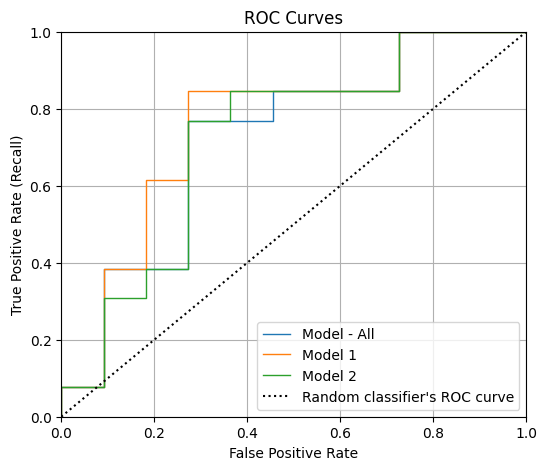

In [46]:
# Plotting the ROC curve

plt.figure(figsize=(6, 5))  # extra code – not needed, just formatting
plt.plot(fpr, tpr, linewidth=1, label="Model - All")
plt.plot(fpr1, tpr1, linewidth=1, label="Model 1")
plt.plot(fpr2, tpr2, linewidth=1, label="Model 2")
plt.plot([0, 1], [0, 1], 'k:', label="Random classifier's ROC curve")

plt.title('ROC Curves')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.grid()
plt.axis([0, 1, 0, 1])
plt.legend(loc="lower right", fontsize=10)
plt.show()

In [47]:
# Print AUC of ROC curves
print("AUC score - All variables: ", round(auc_score, 4))
print("AUC score - Model 1: ", round(auc_score1, 4))
print("AUC score - Model 2: ", round(auc_score2, 4))

AUC score - All variables:  0.7203
AUC score - Model 1:  0.7552
AUC score - Model 2:  0.7203


Breast Cancer Imaging Dataset

In [48]:
# Read dataset
df2 = pd.read_csv('G:/My Drive/Spring 2024/Advanced_Healthcare/Week3/breast-cancer.csv')

In [5]:
df2.isnull().sum()

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [6]:
df2.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [8]:
# We have a balanced dataset
df2['diagnosis'].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

In [19]:
# Replace values of diagnosis column
df2['malignant'] = df2['diagnosis'].replace({'M':1, 'B':0}).infer_objects(copy=False)

C:\Users\mfncn\AppData\Local\Temp\ipykernel_21044\3326140057.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df2['malignant'] = df2['diagnosis'].replace({'M':1, 'B':0}).infer_objects(copy=False)


In [21]:
df2

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,malignant
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,1
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,1
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,1
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,1
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,1
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,1
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,1
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,1


In [22]:
# Split data into X and y
X = df2.iloc[:, 2:-1]
y = df2['malignant']

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

# Scale features
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

In [47]:
# Train logistic regression model
logreg = LogisticRegression()
logreg.fit(X_train_std, y_train)

# Reshape data into 1D arrays
y_train = np.ravel(y_train)
y_test = np.ravel(y_test)

# Make predictions
y_pred = logreg.predict(X_test_std)

# Measure test accuracy, recall and precision
test_acc = accuracy_score(y_test, y_pred)
print('Logit model accuracy:', test_acc)

test_recall = recall_score(y_test, y_pred)
print('Logit model recall:', test_recall)

test_prec = precision_score(y_test, y_pred)
print('Logit model precision:', test_prec)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)
print('Logit confusion matrix: ')
print(cm)

# Prepare to plot ROC curve
y_scores = logreg.decision_function(X_test_std)
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
auc_score = roc_auc_score(y_test, y_scores)

Logit model accuracy: 0.9122807017543859
Logit model recall: 0.8421052631578947
Logit model precision: 0.8888888888888888
Logit confusion matrix: 
[[72  4]
 [ 6 32]]


Model 1

In [40]:
df2.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'malignant'],
      dtype='object')

In [48]:
# Split data into X and y
X = df2[['radius_mean', 'texture_mean', 'smoothness_mean', 'symmetry_mean']]
y = df2['malignant']

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Scale features
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

# Train logistic regression model
logreg1 = LogisticRegression(random_state=21)
logreg1.fit(X_train_std, y_train)

# Reshape data into 1D arrays
#y_train = np.ravel(y_train)
#y_test = np.ravel(y_test)

# Make predictions
y_pred1 = logreg1.predict(X_test_std)

# Measure test accuracy, recall and precision
test_acc1 = accuracy_score(y_test, y_pred1)
print('Logit model accuracy:', test_acc1)

test_recall1 = recall_score(y_test, y_pred1)
print('Logit model recall:', test_recall1)

test_prec1 = precision_score(y_test, y_pred1)
print('Logit model precision:', test_prec1)

# Create confustion matrix
cm1 = confusion_matrix(y_test, y_pred1)
print('Logit confusion matrix: ')
print(cm1)

# Prepare to plot ROC curve
y_scores1 = logreg1.decision_function(X_test_std)
fpr1, tpr1, thresholds1 = roc_curve(y_test, y_scores1)
auc_score1 = roc_auc_score(y_test, y_scores1)

Logit model accuracy: 0.9210526315789473
Logit model recall: 0.868421052631579
Logit model precision: 0.8918918918918919
Logit confusion matrix: 
[[72  4]
 [ 5 33]]


Model 2

In [49]:
# Split data into X and y
X = df2[['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'symmetry_mean', 'fractal_dimension_mean']]
y = df2['malignant']

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Scale features
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

# Train logistic regression model
logreg2 = LogisticRegression(random_state=21)
logreg2.fit(X_train_std, y_train)

# Reshape data into 1D arrays
#y_train = np.ravel(y_train)
#y_test = np.ravel(y_test)

# Make predictions
y_pred2 = logreg2.predict(X_test_std)

# Measure test accuracy, recall and precision
test_acc2 = accuracy_score(y_test, y_pred2)
print('Logit model accuracy:', test_acc2)

test_recall2 = recall_score(y_test, y_pred2)
print('Logit model recall:', test_recall2)

test_prec2 = precision_score(y_test, y_pred2)
print('Logit model precision:', test_prec2)

# Create confustion matrix
cm2 = confusion_matrix(y_test, y_pred2)
print('Logit confusion matrix: ')
print(cm2)

# Prepare to plot ROC curve
y_scores2 = logreg2.decision_function(X_test_std)
fpr2, tpr2, thresholds2 = roc_curve(y_test, y_scores2)
auc_score2 = roc_auc_score(y_test, y_scores2)

Logit model accuracy: 0.9385964912280702
Logit model recall: 0.8636363636363636
Logit model precision: 0.9743589743589743
Logit confusion matrix: 
[[69  1]
 [ 6 38]]


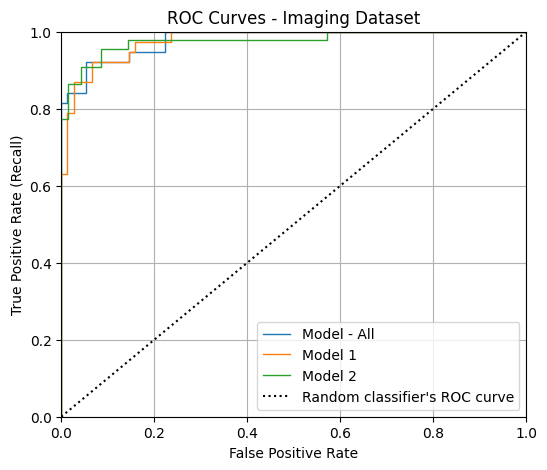

In [50]:
# Plotting the ROC curve

plt.figure(figsize=(6, 5))  # extra code – not needed, just formatting
plt.plot(fpr, tpr, linewidth=1, label="Model - All")
plt.plot(fpr1, tpr1, linewidth=1, label="Model 1")
plt.plot(fpr2, tpr2, linewidth=1, label="Model 2")
plt.plot([0, 1], [0, 1], 'k:', label="Random classifier's ROC curve")

plt.title('ROC Curves - Imaging Dataset')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.grid()
plt.axis([0, 1, 0, 1])
plt.legend(loc="lower right", fontsize=10)
plt.show()

In [51]:
# Print AUC of ROC curves
print("AUC score - All variables: ", round(auc_score, 4))
print("AUC score - Model 1: ", round(auc_score1, 4))
print("AUC score - Model 2: ", round(auc_score2, 4))

AUC score - All variables:  0.9799
AUC score - Model 1:  0.9782
AUC score - Model 2:  0.9766
